# 07 — Tổng hợp: một tấm ảnh tốn bao nhiêu, và nên kéo đòn bẩy nào

Notebook cuối ghép các mảnh của cả bộ lại thành câu trả lời cho câu hỏi của dự án: **chạy một mô
hình thị giác–ngôn ngữ trên GPU 6 GB, thời gian nằm ở đâu, và đòn bẩy nào đáng kéo?**

| Mục | Nội dung | Dựa trên |
|---|---|---|
| 1 | Một tấm ảnh thành bao nhiêu token | notebook 03 |
| 2 | Thời gian nằm ở đâu — đo trên máy này | notebook 02, 04 |
| 3 | Bản đồ đòn bẩy: dự đoán và đo thực tế | notebook 02 (Amdahl), 05 |
| 4 | Biểu đồ đánh đổi | notebook 00, 01 (lỗi 5) |
| 5 | Kết luận kỹ thuật | cả bộ |

In [1]:
import json, sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")                      # main-branch code lives one level up
from bench.harness import load_samples, PROMPT
from bench.metrics import wilson_interval, paired_accuracy

RESULTS = Path("../results")
plt.rcParams.update({"figure.figsize": (7, 3.6), "figure.dpi": 110})
dev = "cuda"

def load(name):
    return json.loads((RESULTS / name).read_text())

## 1. Một tấm ảnh thành bao nhiêu token

Mô hình ngôn ngữ chỉ nhận một chuỗi vector. Ảnh được biến thành vector cùng số chiều với embedding
chữ rồi **chèn thẳng vào chuỗi** (notebook 03): cắt thành 13 ô, mỗi ô 729 mảnh qua bộ mã hoá, pixel
shuffle nén còn 81 token mỗi ô.

In [2]:
from transformers import AutoProcessor, AutoModelForImageTextToText
MODEL = "HuggingFaceTB/SmolVLM-Instruct"
proc = AutoProcessor.from_pretrained(MODEL)
model = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16).to(dev).eval()

sample = load_samples(1, seed=0)[0]
msg = [{"role": "user", "content": [{"type": "image"},
                                    {"type": "text", "text": PROMPT.format(q=sample["query"])}]}]
inputs = proc(text=proc.apply_chat_template(msg, add_generation_prompt=True),
              images=[sample["image"]], return_tensors="pt").to(dev)
ids = inputs["input_ids"][0]
n_img = int((ids == model.config.image_token_id).sum())
print(f"image {sample['image'].size} -> {inputs['pixel_values'].shape[1]} tiles")
print(f"input sequence: {ids.numel()} tokens, of which image tokens {n_img} ({100 * n_img / ids.numel():.1f}%)")
print(f"patches through the vision encoder: {inputs['pixel_values'].shape[1] * 729}")

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

image (800, 557) -> 13 tiles
input sequence: 1251 tokens, of which image tokens 1053 (84.2%)
patches through the vision encoder: 9477


Ảnh chiếm hơn 80% chuỗi đầu vào. Câu hỏi, khuôn mẫu hội thoại và chỉ dẫn cộng lại chỉ khoảng 200
token. Nhưng như notebook 03 chỉ ra, con số thật sự đắt là **9.477 mảnh** đi qua bộ mã hoá, không
phải 1.053 token mô hình ngôn ngữ nhìn thấy.

## 2. Thời gian nằm ở đâu

Đo từng thành phần bằng CUDA event (notebook 02), sau khi làm nóng. Pha cuối là **sinh câu trả lời**:
`max_new_tokens=32` chỉ là giới hạn trên, câu trả lời ngắn dừng sớm (notebook 04, mục 5.1).

In [3]:
def timed(fn, reps=5):
    for _ in range(2): fn()
    ts, out = [], None
    for _ in range(reps):
        s, e = torch.cuda.Event(True), torch.cuda.Event(True)
        torch.cuda.synchronize(); s.record(); out = fn(); e.record(); torch.cuda.synchronize()
        ts.append(s.elapsed_time(e))
    return float(np.median(ts)), out

inner = model.model
pix = inputs["pixel_values"].flatten(0, 1).to(model.dtype)
gen = lambda: model.generate(**inputs, max_new_tokens=32, do_sample=False)
with torch.no_grad():
    t_vis, vis_out = timed(lambda: inner.vision_model(pixel_values=pix))
    t_con, _ = timed(lambda: inner.connector(vis_out.last_hidden_state))
    t_fwd, _ = timed(lambda: model(**inputs))                # vision + connector + LM prefill
    t_gen, out = timed(gen)
n_new = out.shape[1] - ids.numel()
parts = {"vision encoder": t_vis, "connector": t_con, "LM prefill": t_fwd - t_vis - t_con,
         f"generate the answer ({n_new} tokens)": t_gen - t_fwd}
for k, v in parts.items():
    print(f"{k:<32} {v:7.1f} ms  {100 * v / t_gen:5.1f}%")
print(f"{'total':<32} {t_gen:7.1f} ms")
print("answer:", proc.decode(out[0, ids.numel():], skip_special_tokens=True).strip(), "| gold:", sample["gold"])
del model; torch.cuda.empty_cache()

vision encoder                     531.4 ms   53.5%
connector                            2.7 ms    0.3%
LM prefill                         272.0 ms   27.4%
generate the answer (7 tokens)     188.1 ms   18.9%
total                              994.2 ms
answer: 2022. | gold: 2022


Một câu hỏi đơn lẻ dao động từ lần chạy này sang lần chạy khác — nhất là phần sinh câu trả lời, vốn
phụ thuộc câu trả lời dài bao nhiêu token. Bảng phân rã của dự án (`breakdown.json`, 12 câu × 3 lần đo)
cho bức tranh ổn định hơn: **bộ mã hoá thị giác chiếm khoảng một nửa thời gian**, gần gấp đôi prefill
của mô hình ngôn ngữ, và phần sinh câu trả lời chiếm phần còn lại. Lần đo đơn lẻ ở trên cho cùng thứ tự
đó.

Mỗi pha bị giới hạn bởi một tài nguyên khác nhau (notebook 04, 05):

| Pha | Giới hạn bởi | Vì sao |
|---|---|---|
| Mã hoá thị giác | tính toán | 9.477 mảnh × 413 triệu tham số ≈ 8,7 TFLOP |
| Prefill ngôn ngữ | tính toán | 1.251 token × 1,6 tỉ tham số ≈ 4,2 TFLOP |
| Sinh câu trả lời | băng thông bộ nhớ (bf16), CPU (nf4) | mỗi token đọc toàn bộ trọng số; ~1.000 kernel mỗi token |

## 3. Bản đồ đòn bẩy

Mỗi đòn bẩy tác động vào một số pha. Định luật Amdahl tổng quát (notebook 02, mục 8) cho dự đoán,
với hệ số tăng tốc của bộ mã hoá lấy từ **số ô** và của prefill lấy từ **số token đầu vào thật**.
Các file kết quả cho con số đo được; độ chính xác so theo cặp với bản gốc **của cùng lần chạy**
(notebook 00):

In [4]:
shares = load("breakdown.json")["share_pct"]
p_vis = (shares["vision"] + shares["connector"]) / 100
p_pre = shares["llm_prefill"] / 100
sweep, confirm = load("gate2_sweep.json"), load("gate2_confirm.json")

def input_tokens(run, cfg):
    return float(np.median([r["input_tokens"] for r in run["records"] if r["config"] == cfg]))

def predicted(run, cfg, tiles):
    t = input_tokens(run, cfg) / input_tokens(run, "baseline")
    return 1 / ((1 - p_vis - p_pre) + p_vis * tiles / 13 + p_pre * t)

def lever(run, cfg, tiles):
    pa = paired_accuracy(run["records"], "baseline", cfg)
    d = 100 * (run["configs"][cfg]["accuracy"] - run["configs"]["baseline"]["accuracy"])
    return (predicted(run, cfg, tiles), run["paired_speedup_vs_baseline"][cfg]["median_speedup"],
            d, pa["p_value"], pa["n_pairs"])

rows = [("edge 768 (13 -> 5 tiles)", "encoder + prefill", *lever(confirm, "edge768(edge=768)", 5)),
        ("single tile", "encoder + prefill", *lever(sweep, "nosplit(nosplit)", 1))]
for m in ["uniform", "random", "pool", "norm"]:
    rows.append((f"prune to 25%, {m}", "prefill only", *lever(sweep, f"keep0.25:{m}(keep=0.25,{m})", 13)))
print(f"{'lever':<26} {'touches':<18} {'Amdahl':>7} {'measured':>9} {'accuracy':>9} {'p':>8} {'n':>4}")
for name, touches, pred, sp, d, p, n in rows:
    print(f"{name:<26} {touches:<18} {pred:6.2f}x {sp:8.2f}x {d:+8.1f} {p:8.4f} {n:>4}")

nf4 = load("gate5_nf4.json")
same = {r["sample_id"] for r in nf4["records"]}              # bf16 and nf4 on the same 300 questions
bf = [r for r in confirm["records"] if r["config"] == "baseline" and r["sample_id"] in same]
q4 = [r for r in nf4["records"] if r["config"] == "baseline"]
def per_question(recs):                                       # median of each question's two rounds
    by = {}
    for r in recs:
        by.setdefault(r["sample_id"], []).append(r["generate_ms"])
    return {k: np.median(v) for k, v in by.items()}
t_bf, t_nf4 = per_question(bf), per_question(q4)
sp_nf4 = np.median([t_bf[k] / t_nf4[k] for k in same])        # paired, like the other rows
acc = lambda recs: 100 * np.mean([r["correct"] for r in recs])
pa = paired_accuracy([dict(r, config="bf16") for r in bf] + [dict(r, config="nf4") for r in q4], "bf16", "nf4")
print(f"{'nf4 weights':<26} {'bytes, not FLOP':<18} {'  -':>7} {sp_nf4:8.2f}x "
      f"{acc(q4) - acc(bf):+8.1f} "
      f"{pa['p_value']:8.4f} {pa['n_pairs']:>4}   VRAM {confirm['peak_vram_mb']:.0f} -> {nf4['peak_vram_mb']:.0f} MiB")

lever                      touches             Amdahl  measured  accuracy        p    n
edge 768 (13 -> 5 tiles)   encoder + prefill    1.96x     1.92x     -2.2   0.0106 1920
single tile                encoder + prefill    3.75x     3.29x    -28.0   0.0000  100
prune to 25%, uniform      prefill only         1.21x     1.17x    -34.0   0.0000  100
prune to 25%, random       prefill only         1.21x     1.17x    -29.0   0.0000  100
prune to 25%, pool         prefill only         1.21x     1.17x    -37.0   0.0000  100
prune to 25%, norm         prefill only         1.21x     1.16x    -11.0   0.0522  100
nf4 weights                bytes, not FLOP          -     0.95x     -1.7   0.5327  300   VRAM 4891 -> 2169 MiB


Đọc bảng theo cột "touches" (tác động vào pha nào):

- **Đòn bẩy chạm vào bộ mã hoá** (giảm số ô) cho tăng tốc lớn nhất, và dự đoán Amdahl khớp tốt với
  cạnh 768. Với "một ô", số đo thấp hơn dự đoán: một ô đơn lẻ dùng GPU kém hiệu quả hơn một lô 13 ô
  (notebook 03, mục 6), nên bộ mã hoá không nhanh lên đủ 13 lần. Cái giá của "một ô" là gần 30 điểm
  độ chính xác: ở 384×384, chữ số trên biểu đồ không còn đọc được.
- **Đòn bẩy chỉ chạm vào prefill** (cắt token sau bộ mã hoá) nằm sát dự đoán Amdahl — và dự đoán đó
  đã thấp, vì prefill chỉ khoảng một phần tư thời gian. Bốn cách chọn token cho **cùng** tăng tốc,
  nhưng độ chính xác rất khác nhau: giữ các token có chuẩn lớn nhất (`norm`) mất ít hơn hẳn ba cách
  còn lại (notebook 01, lỗi 8).
- **nf4** không chạm vào FLOP nào; nó giảm byte. Kết quả: bộ nhớ giảm hơn một nửa, thời gian **tăng**
  (notebook 05: prefill thêm giải lượng tử, decode bị giới hạn bởi phần việc phía CPU).

## 4. Biểu đồ đánh đổi

Mọi cấu hình của lần quét, trên cùng các câu hỏi, với khoảng tin cậy Wilson tính **một quan sát cho
mỗi câu** (notebook 01, lỗi 5):

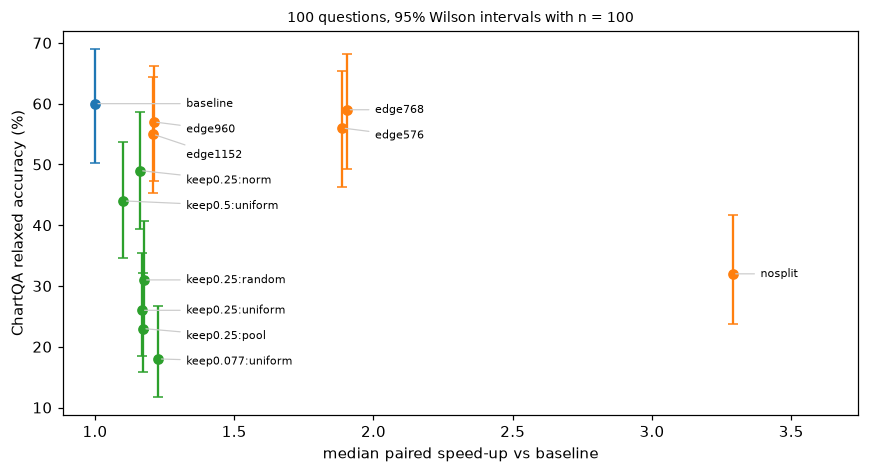

In [5]:
per = defaultdict(lambda: defaultdict(list))
for r in sweep["records"]:
    per[r["config"]][r["sample_id"]].append(int(r["correct"]))
fam = {"baseline": "C0", "nosplit": "C1", "edge": "C1", "keep": "C2"}
from bench.plot import label_positions                              # the README figure's label layout
fig, ax = plt.subplots(figsize=(8, 4.4))
points = []
for cfg, qs in per.items():
    n_q = len(qs)
    k = sum(np.mean(v) for v in qs.values())                       # one observation per question
    lo, hi = wilson_interval(k, n_q)
    sp = 1.0 if cfg == "baseline" else sweep["paired_speedup_vs_baseline"][cfg]["median_speedup"]
    acc = 100 * k / n_q
    color = next(c for key, c in fam.items() if cfg.startswith(key))
    ax.errorbar(sp, acc, yerr=[[acc - 100 * lo], [100 * hi - acc]], fmt="o", c=color, capsize=3)
    points.append({"key": cfg.split("(")[0], "speed": sp, "acc": acc})
pos = label_positions(points)
for d in points:
    ax.annotate(d["key"], (d["speed"], d["acc"]), xytext=pos[id(d)], textcoords="data", fontsize=7,
                va="center", arrowprops=dict(arrowstyle="-", color="0.8", lw=0.8))
ax.set_xlim(right=max(d["speed"] for d in points) + 0.45)
ax.set_xlabel("median paired speed-up vs baseline"); ax.set_ylabel("ChartQA relaxed accuracy (%)")
ax.set_title(f"{n_q} questions, 95% Wilson intervals with n = {n_q}", fontsize=9)
plt.tight_layout(); plt.show()

Hai cụm tách bạch: các cấu hình **giảm số ô** (cam) trải dài sang phải — nhanh hơn — còn mọi cấu hình
**cắt token** (xanh lá) dồn quanh 1,1–1,2×, bất kể giữ bao nhiêu token. Trong cụm cắt token, `norm`
nằm cao hơn hẳn các cách còn lại. Mọi đòn bẩy đều **trả giá bằng độ chính xác** so với bản gốc; câu
hỏi kỹ thuật là giá đó có đáng với tốc độ nhận được không.

## 5. Kết luận kỹ thuật

1. **Đo trước khi tối ưu.** Đếm token gợi ý mô hình ngôn ngữ là chỗ đắt; đo thời gian cho thấy bộ mã
   hoá thị giác mới là chỗ đắt. Kỹ thuật được bàn nhiều nhất (cắt token sau mã hoá) nhắm vào phần
   không đủ lớn.
2. **Đòn bẩy phải chạm vào phần đắt.** Giảm độ phân giải đầu vào (cạnh 768) gần gấp đôi tốc độ và
   thông lượng dịch vụ, đổi lấy khoảng 7 điểm độ chính xác — một đánh đổi thật, có ý nghĩa thống kê.
3. **Nếu vẫn cắt token, hãy chọn token bằng thông tin từ mô hình.** Chuẩn của token là một tín hiệu
   rẻ mà đã tốt hơn hẳn chọn cách đều hay ngẫu nhiên. Nhưng tốc độ vẫn bị trần Amdahl của prefill.
4. **Lượng tử hoá giảm byte, không giảm FLOP.** Ở bài toán nặng prefill, nf4 chỉ mua bộ nhớ; bộ nhớ
   đó có giá trị khi dùng cho batching (notebook 06).
5. **Mọi con số cần đi kèm độ bất định đúng, và phải sinh ra từ dữ liệu.** Mười một lỗi đo đạc của
   notebook 01 đều cho ra những con số trông hợp lý.

Những hướng còn bỏ ngỏ, theo thứ tự đáng làm:
- **Lượng tử hoá cả activation (W8A8, FP8) cho bộ mã hoá** — phần compute-bound chiếm đa số thời gian,
  nơi duy nhất lượng tử hoá có thể mua tốc độ trong bài toán này.
- **Cắt token theo điểm attention** (kiểu FastV) — tín hiệu mạnh hơn chuẩn của token; vẫn bị trần
  Amdahl của prefill.
- **CUDA graph hoặc kernel 4 bit hợp nhất**, để nf4 thành tốc độ thật ở pha decode.
- **Batching ở máy chủ**, dùng bộ nhớ mà nf4 giải phóng.